In [4]:
import powerlaw
import numpy as np
import matplotlib.pyplot as plt
import os
import sys
from collections import Counter
# import numpy as np
# import seaborn as sns
import xgi
# from matplotlib import cm
# from draw import *
notebook_dir = os.getcwd()  # This gets the current working directory in Jupyter
parent_dir = os.path.abspath(os.path.join(notebook_dir, '..'))
if parent_dir not in sys.path:
    sys.path.append(parent_dir)
from sod import *
from sod.simpliciality import edit_simpliciality
# from sod.simpliciality import edge_rewiring
from edge_rewiring import edge_rewiring_alg
from edge_rewiring import edge_rewiring_exper
from edge_rewiring import power_law

SyntaxError: invalid non-printable character U+200A (power_law.py, line 46)

In [3]:
from edge_rewiring import edge_rewiring_model
import matplotlib.pyplot as plt

# Generate hypergraph
# H = xgi.load_xgi_data(edge_rewiring_exper.datasets[0], max_order=11)
H = edge_rewiring_model.edge_rewire_model(.5, 8635, 540, 100, min_size=2, max_size=None)


ImportError: cannot import name 'edge_rewiring_model' from 'edge_rewiring' (unknown location)

Unnamed Hypergraph with 50 nodes and 568 hyperedges
{0: 25, 1: 34, 2: 31, 3: 27, 4: 38, 5: 22, 6: 32, 7: 29, 8: 38, 9: 28, 10: 31, 11: 33, 12: 40, 13: 29, 14: 25, 15: 34, 16: 23, 17: 27, 18: 34, 19: 28, 20: 37, 21: 24, 22: 28, 23: 37, 24: 40, 25: 29, 26: 23, 27: 31, 28: 31, 29: 19, 30: 35, 31: 31, 32: 22, 33: 35, 34: 33, 35: 35, 36: 25, 37: 22, 38: 31, 39: 36, 40: 20, 41: 33, 42: 32, 43: 30, 44: 26, 45: 31, 46: 26, 47: 19, 48: 19, 49: 33}
[25, 34, 31, 27, 38, 22, 32, 29, 38, 28, 31, 33, 40, 29, 25, 34, 23, 27, 34, 28, 37, 24, 28, 37, 40, 29, 23, 31, 31, 19, 35, 31, 22, 35, 33, 35, 25, 22, 31, 36, 20, 33, 32, 30, 26, 31, 26, 19, 19, 33]
[19, 19, 19, 20, 22, 22, 22, 23, 23, 24, 25, 25, 25, 26, 26, 27, 27, 28, 28, 28, 29, 29, 29, 30, 31, 31, 31, 31, 31, 31, 31, 32, 32, 33, 33, 33, 33, 34, 34, 34, 35, 35, 35, 36, 37, 37, 38, 38, 40, 40]
Calculating best minimal value for power law fit
Power-law alpha: 14.6129
xmin: 33.0
Sigma: 3.3016
Loglikelihood ratio R: -0.1355
p-value: 0.4952


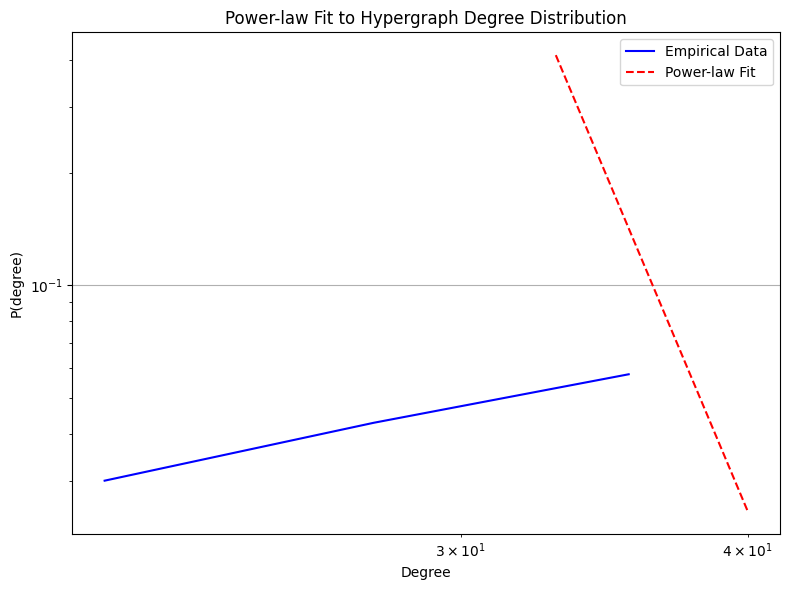

In [214]:
# Normal
print(H)
degree_dict = H.degree()
print(degree_dict)
degree_list = list(degree_dict.values())
print(degree_list)
sorted_degrees = sorted(degree_dict.values())
print(sorted_degrees)
truncated_degrees = [d for d in degree_list if d >= 35]

fit = powerlaw.Fit(sorted_degrees, xmin=0)
# print(fit.fixed_xmin)
print(f"Power-law alpha: {fit.power_law.alpha:.4f}")
print(f"xmin: {fit.xmin}")
print(f"Sigma: {fit.power_law.sigma:.4f}")

R, p = fit.distribution_compare('power_law', 'exponential')
print(f"Loglikelihood ratio R: {R:.4f}")
print(f"p-value: {p:.4f}")

plt.figure(figsize=(8, 6))
powerlaw.plot_pdf(degree_list, color='b', label='Empirical Data')
fit.power_law.plot_pdf(color='r', linestyle='--', label='Power-law Fit')
plt.xlabel("Degree")
plt.ylabel("P(degree)")
plt.title("Power-law Fit to Hypergraph Degree Distribution")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Unnamed Hypergraph with 50 nodes and 413 hyperedges
{0: 13, 1: 25, 2: 23, 3: 22, 4: 10, 5: 35, 6: 15, 7: 25, 8: 14, 9: 12, 10: 35, 11: 19, 12: 20, 13: 27, 14: 26, 15: 10, 16: 26, 17: 19, 18: 29, 19: 23, 20: 25, 21: 8, 22: 33, 23: 31, 24: 16, 25: 3, 26: 24, 27: 25, 28: 21, 29: 41, 30: 36, 31: 27, 32: 13, 33: 26, 34: 32, 35: 35, 36: 37, 37: 11, 38: 20, 39: 34, 40: 8, 41: 22, 42: 16, 43: 21, 44: 28, 45: 20, 46: 19, 47: 13, 48: 16, 49: 24}
[13, 25, 23, 22, 10, 35, 15, 25, 14, 12, 35, 19, 20, 27, 26, 10, 26, 19, 29, 23, 25, 8, 33, 31, 16, 3, 24, 25, 21, 41, 36, 27, 13, 26, 32, 35, 37, 11, 20, 34, 8, 22, 16, 21, 28, 20, 19, 13, 16, 24]
[3, 8, 8, 10, 10, 11, 12, 13, 13, 13, 14, 15, 16, 16, 16, 19, 19, 19, 20, 20, 20, 21, 21, 22, 22, 23, 23, 24, 24, 25, 25, 25, 25, 26, 26, 26, 27, 27, 28, 29, 31, 32, 33, 34, 35, 35, 35, 36, 37, 41]
truncated_degrees: [35, 35, 41, 36, 35, 37]
Power-law alpha: 25.7970
xmin: 35.0
Sigma: 10.1233
Loglikelihood ratio R: 0.1231
p-value: 0.2307


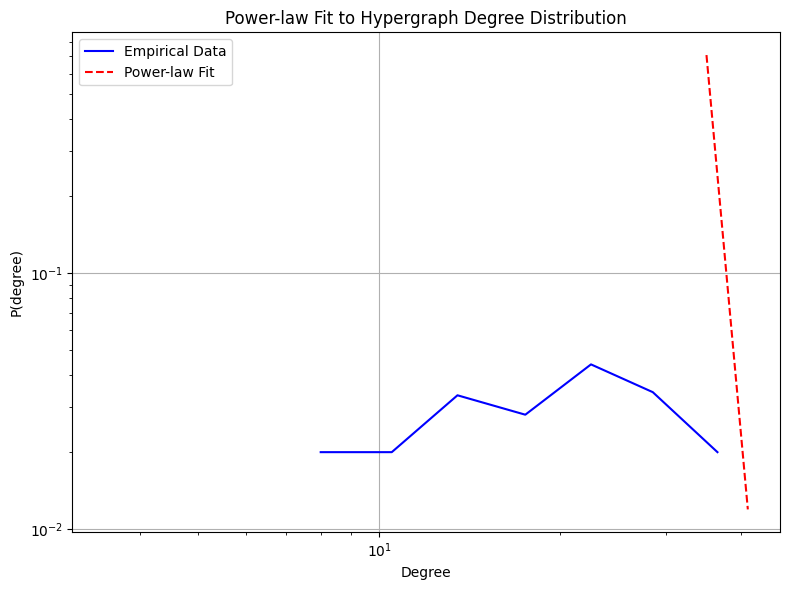

In [204]:
#Turncate
print(H)
degree_dict = H.degree()
print(degree_dict)
degree_list = list(degree_dict.values())
print(degree_list)
sorted_degrees = sorted(degree_dict.values())
print(sorted_degrees)
# Truncate the degree list
truncated_degrees = [d for d in degree_list if d >= 35]
print(f"truncated_degrees: {truncated_degrees}")

fit2 = powerlaw.Fit(truncated_degrees, xmin=35)
# print(fit.fixed_xmin)
print(f"Power-law alpha: {fit2.power_law.alpha:.4f}")
print(f"xmin: {fit2.xmin}")
print(f"Sigma: {fit2.power_law.sigma:.4f}")

R, p = fit2.distribution_compare('power_law', 'exponential')
print(f"Loglikelihood ratio R: {R:.4f}")
print(f"p-value: {p:.4f}")

plt.figure(figsize=(8, 6))
powerlaw.plot_pdf(degree_list, color='b', label='Empirical Data')
fit2.power_law.plot_pdf(color='r', linestyle='--', label='Power-law Fit')
plt.xlabel("Degree")
plt.ylabel("P(degree)")
plt.title("Power-law Fit to Hypergraph Degree Distribution")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Hypergraph named contact-primary-school with 242 nodes and 106879 hyperedges
[125, 144, 157, 178, 204, 216, 218, 234, 243, 245, 255, 255, 261, 273, 273, 279, 294, 307, 308, 320, 328, 347, 367, 369, 371, 371, 379, 385, 390, 392, 393, 402, 402, 403, 415, 416, 421, 433, 434, 439, 451, 456, 463, 472, 479, 494, 510, 517, 537, 558, 563, 566, 569, 569, 576, 577, 579, 592, 597, 618, 620, 630, 632, 636, 637, 651, 656, 658, 668, 681, 682, 683, 686, 686, 686, 687, 688, 689, 689, 689, 690, 693, 704, 704, 708, 711, 720, 726, 728, 733, 746, 747, 749, 750, 755, 756, 766, 768, 771, 774, 784, 787, 787, 792, 802, 804, 809, 810, 816, 817, 825, 827, 833, 833, 836, 857, 859, 871, 872, 874, 877, 889, 895, 907, 909, 912, 913, 915, 924, 926, 931, 931, 932, 944, 946, 957, 964, 966, 966, 967, 971, 975, 976, 980, 981, 982, 987, 999, 1004, 1004, 1005, 1020, 1030, 1034, 1037, 1039, 1044, 1046, 1047, 1051, 1058, 1066, 1069, 1078, 1088, 1101, 1105, 1107, 1114, 1124, 1140, 1172, 1176, 1177, 1178, 1201, 1205, 1208, 12

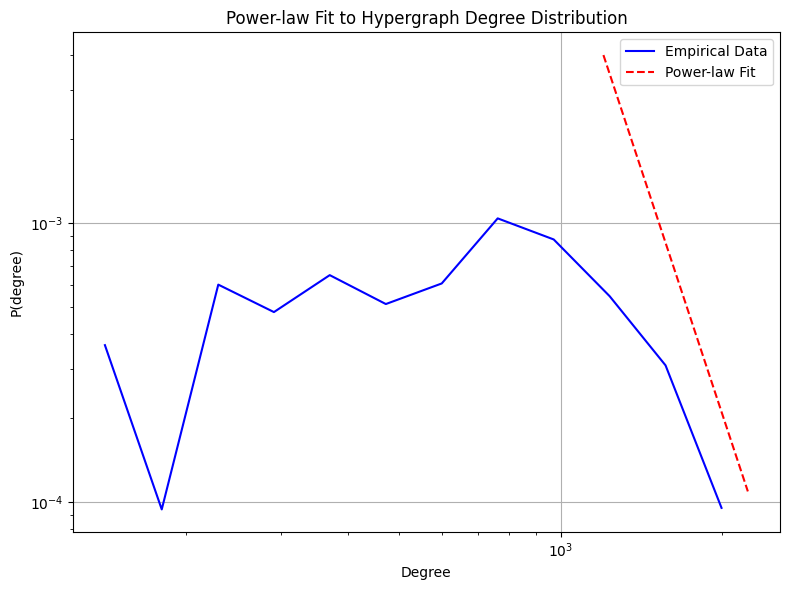

In [187]:
from edge_rewiring import edge_rewiring_alg

H = xgi.load_xgi_data(edge_rewiring_exper.datasets[0])
# es = edit_simpliciality(H, min_size=2)
# print(f"Edit simpliciality: {es}")

print(H)
degree_dict = H.degree()
#print(degree_dict)
degree_list = list(degree_dict.values())
#print(degree_list)
sorted_degrees = sorted(degree_dict.values())
filtered_degrees = [d for d in sorted_degrees if d > 0]
print(filtered_degrees)

fit = powerlaw.Fit(filtered_degrees)
print(f"Power-law alpha: {fit.power_law.alpha:.4f}")
print(f"xmin: {fit.xmin}")
print(f"Sigma: {fit.power_law.sigma:.4f}")

R, p = fit.distribution_compare('power_law', 'exponential')
print(f"Loglikelihood ratio R: {R:.4f}")
print(f"p-value: {p:.4f}")

plt.figure(figsize=(8, 6))
powerlaw.plot_pdf(filtered_degrees, color='b', label='Empirical Data')
fit.power_law.plot_pdf(color='r', linestyle='--', label='Power-law Fit')
plt.xlabel("Degree")
plt.ylabel("P(degree)")
plt.title("Power-law Fit to Hypergraph Degree Distribution")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
